# Úloha 1: Lineární a nelineární oscilátory

---

## 1. Teoretický přepis na soustavy ODE prvního řádu
Pro numerické řešení v knihovně `scipy` je nutné přepsat diferenciální rovnice druhého řádu na soustavy dvou obyčejných diferenciálních rovnic (ODE) prvního řádu pomocí substituce rychlosti $v = \dot{x}$.
### A) Lineární tlumený oscilátor
Původní rovnice:
$$\ddot{x} + 2\delta\dot{x} + \omega_0^2 x = 0$$
Po substituci $v = \dot{x}$ dostáváme soustavu:
$$\dot{x} = v$$
$$\dot{v} = -2\delta v - \omega_0^2 x$$

### B) Duffingův oscilátor
Původní rovnice s periodickým buzením:
$$\ddot{x} + \delta\dot{x} + \alpha x + \beta x^3 = \gamma \cos(\omega t)$$
Po substituci $v = \dot{x}$ dostáváme soustavu:
$$\dot{x} = v$$
$$\dot{v} = -\delta v - \alpha x - \beta x^3 + \gamma \cos(\omega t)$$

---
## 2. Implementace v Pythonu

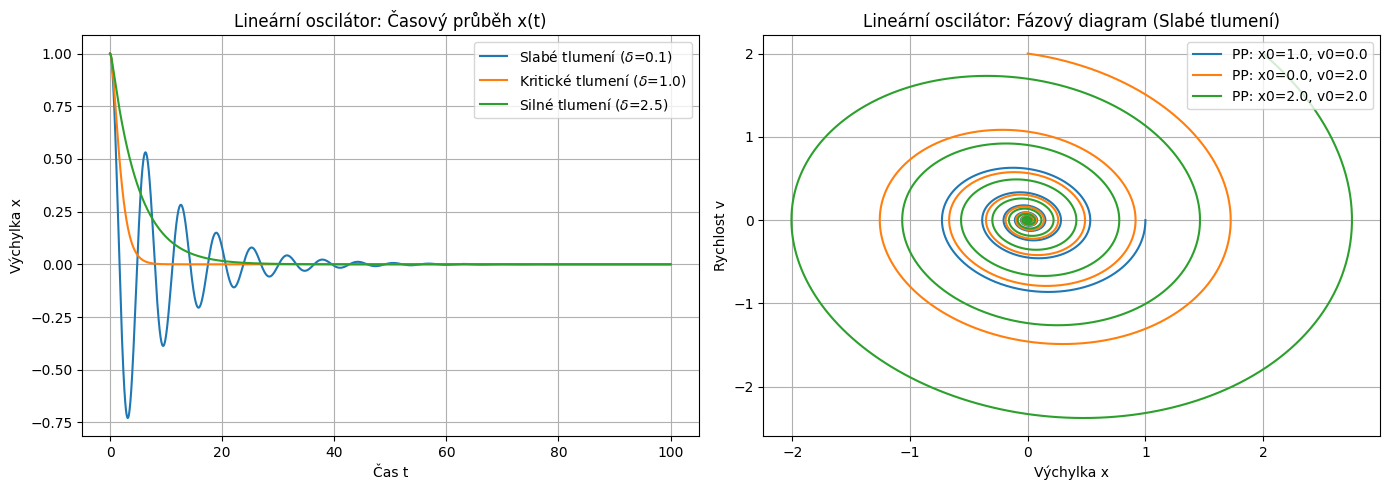

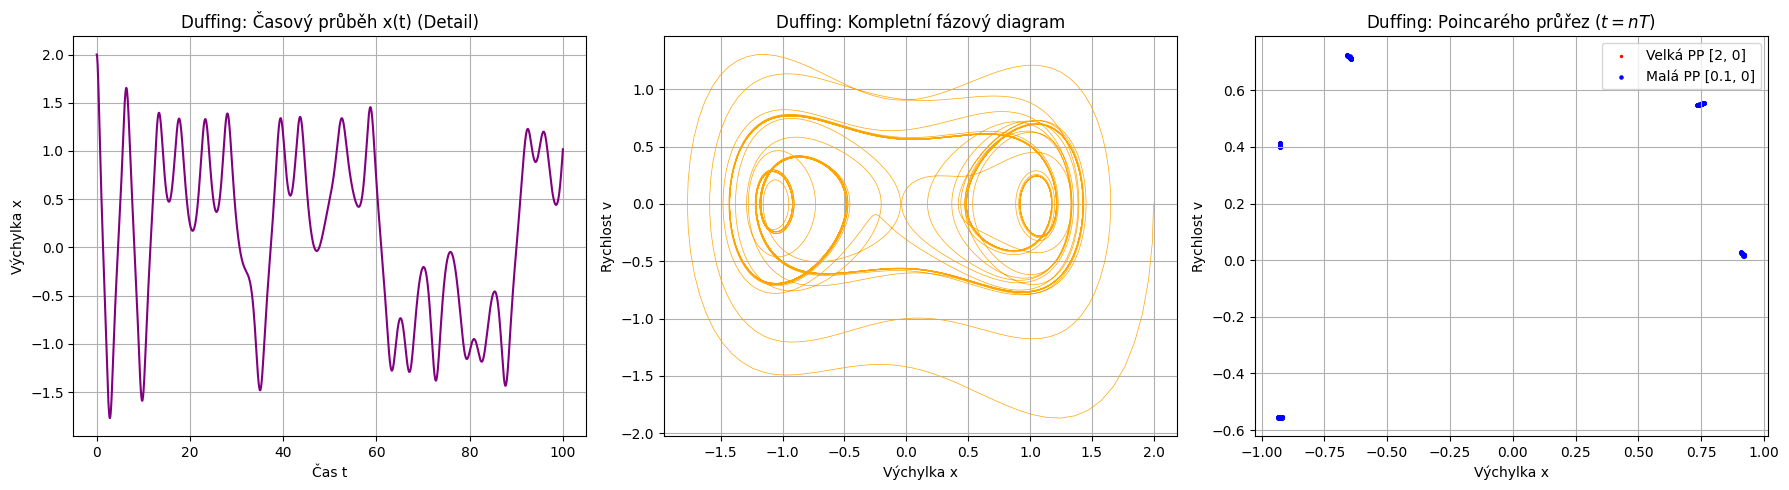

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def linear_oscillator(t, z, omega0, delta):
    x, v = z
    dxdt = v
    dvdt = -2 * delta * v - (omega0**2) * x
    return [dxdt, dvdt]

def duffing_oscillator(t, z, delta, alpha, beta, gamma, omega):
    x, v = z
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * (x**3) + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 10000)

initial_conditions = [
    [1.0, 0.0],
    [0.0, 2.0],
    [2.0, 2.0]
]

# VYKRESLENÍ: LINEÁRNÍ OSCILÁTOR
omega0 = 1.0
damping_modes = {'Slabé': 0.1, 'Kritické': 1.0, 'Silné': 2.5}

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for mode, delta in damping_modes.items():
    sol = solve_ivp(linear_oscillator, t_span, initial_conditions[0], args=(omega0, delta), t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f'{mode} tlumení ($\delta$={delta})')
plt.title('Lineární oscilátor: Časový průběh x(t)')
plt.xlabel('Čas t')
plt.ylabel('Výchylka x')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for ic in initial_conditions:
    sol = solve_ivp(linear_oscillator, t_span, ic, args=(omega0, damping_modes['Slabé']), t_eval=t_eval)
    plt.plot(sol.y[0], sol.y[1], label=f'PP: x0={ic[0]}, v0={ic[1]}')
plt.title('Lineární oscilátor: Fázový diagram (Slabé tlumení)')
plt.xlabel('Výchylka x')
plt.ylabel('Rychlost v')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# VYKRESLENÍ: DUFFINGŮV OSCILÁTOR
d_delta, d_alpha, d_beta, d_gamma, d_omega = 0.2, -1.0, 1.0, 0.3, 1.2
T = 2 * np.pi / d_omega

t_span_duffing = (0, 2000)
t_poincare = np.arange(0, t_span_duffing[1], T)

sol_duff_small = solve_ivp(duffing_oscillator, t_span_duffing, [0.1, 0.0], 
                           args=(d_delta, d_alpha, d_beta, d_gamma, d_omega), t_eval=t_poincare)
sol_duff_large = solve_ivp(duffing_oscillator, t_span_duffing, [2.0, 0.0], 
                           args=(d_delta, d_alpha, d_beta, d_gamma, d_omega), t_eval=t_poincare)

ustaleny_stav = t_poincare > 200

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

t_detail = np.linspace(0, 100, 2000)
sol_detail = solve_ivp(duffing_oscillator, (0, 100), [2.0, 0.0], 
                       args=(d_delta, d_alpha, d_beta, d_gamma, d_omega), t_eval=t_detail)
axs[0].plot(sol_detail.t, sol_detail.y[0], color='purple')
axs[0].title.set_text('Duffing: Časový průběh x(t) (Detail)')
axs[0].set_xlabel('Čas t')
axs[0].set_ylabel('Výchylka x')
axs[0].grid(True)

sol_faze = solve_ivp(duffing_oscillator, (0, 300), [2.0, 0.0], 
                     args=(d_delta, d_alpha, d_beta, d_gamma, d_omega), t_eval=np.linspace(0,300,5000))
axs[1].plot(sol_faze.y[0], sol_faze.y[1], lw=0.5, color='orange')
axs[1].title.set_text('Duffing: Kompletní fázový diagram')
axs[1].set_xlabel('Výchylka x')
axs[1].set_ylabel('Rychlost v')
axs[1].grid(True)

axs[2].scatter(sol_duff_large.y[0][ustaleny_stav], sol_duff_large.y[1][ustaleny_stav], s=2, color='red', label='Velká PP [2, 0]')
axs[2].scatter(sol_duff_small.y[0][ustaleny_stav], sol_duff_small.y[1][ustaleny_stav], s=5, color='blue', label='Malá PP [0.1, 0]')
axs[2].title.set_text('Duffing: Poincarého průřez ($t = nT$)')
axs[2].set_xlabel('Výchylka x')
axs[2].set_ylabel('Rychlost v')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

---
## 3. Odpovědi na otázky

### A) Lineární oscilátor

* **Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?**
    * **Slabé tlumení:** Tlumení je malé. Systém vykazuje klasický kmitavý pohyb, kdy výchylka opakovaně prochází rovnovážnou polohou (nulou) s exponenciálně klesající amplitudou. Ve fázovém portrétu trajektorie vytváří spirálu směřující do počátku (stabilní ohnisko).
    * **Kritické tlumení:** Mezní stav, kdy se systém vrátí do rovnovážné polohy v nejkratším možném čase, aniž by došlo k jakémukoliv překmitu (oscilaci) přes nulu.
    * **Silné tlumení:** Odpor prostředí je velmi vysoký. Systém se vrací k nule čistě exponenciálně a velmi pomalu, pohyb je aperiodický a „líný“.

* **Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo kvalitativně ostrý?**
    * Pokud se nacházíme uvnitř oblasti slabého či silného tlumení, drobná změna parametru o několik procent způsobí pouze **plynulou (kvantitativní)** změnu – např. kmity utichnou o něco rychleji nebo se systém vrátí do rovnováhy o něco pomaleji.
    * Samotná hranice kritického tlumení však představuje **kvalitativně ostrý přechod (bifurkaci)**. V tomto přesném bodě se charakteristické kořeny mění z komplexně sdružených na čistě reálné, což skokově mění samotnou podstatu fyzikálního děje z oscilačního na aperiodický.

* **Jaký mechanismus vede k rezonanci u buzeného kmitání?**
    * K rezonanci dochází v okamžiku, kdy se frekvence vnějšího periodického buzení ($\omega$) přiblíží vlastní přirozené frekvenci oscilátoru ($\omega_0$). Vnější síla v takovém případě dodává energii do systému přesně ve fázi s jeho přirozeným pohybem (tlačí ve správný čas správným směrem). Dochází ke kumulaci energie a dramatickému nárůstu amplitudy výchylky.

* **Dá se problém řešit pomocí symbolické matematiky? Jak?**
    * **Ano**, lineární diferenciální rovnice s konstantními koeficienty mají exaktní analytické řešení. V Pythonu lze k tomuto účelu využít knihovnu **SymPy** a její funkci `dsolve()`. Této funkci zadáme symbolicky zapsanou diferenciální rovnici a počáteční podmínky a ona nám vrátí přesný matematický předpis funkce $x(t)$.

---

### B) Duffingův oscilátor

* **Dochází pro dané parametry k chaotickému chování?**
    * **Ano**, pro doporučenou sadu parametrů ($\delta=0.2, \alpha=-1, \beta=1, \gamma=0.3, \omega=1.2$) a velké počáteční podmínky vykazuje Duffingův oscilátor deterministický chaos. Systém vykazuje extrémní citlivost na počáteční podmínky a jeho Poincarého průřez vykresluje fraktální strukturu – tzv. *podivný atraktor*.

* **Jaký je rozdíl mezi malou a velkou počáteční podmínkou?**
    * Jelikož je $\alpha = -1$, systém představuje potenciál se dvěma jamkami oddělenými lokálním maximem v bodě $x=0$.
    * **Malá počáteční podmínka** (např. `[0.1, 0.0]`) znamená, že systém nemá dostatek energie k překonání středové bariéry. Kulička zůstane uvězněná v jedné z potenciálových jamek, nelinearita se tolik neprojeví a pohyb se ustálí v regulárním periodickém režimu (v Poincarého průřezu se zobrazí jako izolovaný bod).
    * **Velká počáteční podmínka** (např. `[2.0, 0.0]`) dodá systému dostatek energie, aby bariéru překonal. Vlivem nelineárního členu a periodického buzení začne systém chaoticky a nepředvídatelně přeskakovat mezi oběma jamkami.

* **Co se stane, když zvýšíte buzení $\gamma$? Mění se počet atraktorů?**
    * Zvyšování amplitudy vnějšího buzení $\gamma$ pumpuje do systému stále více energie. To vede k postupné destrukci stávajících stabilních periodických orbit (atraktorů) skrze sérii zdvojování period (kaskádu bifurkací). Původně oddělené lokální atraktory zanikají a slévají se do jednoho globálního chaotického atraktoru, takže se jejich počet a struktura dramaticky mění.

---
---
# Úloha 2: Programová implementace SIR modelu
---
## 1. Popis SIR modelu a výběr nemocí

SIR model je deterministický kompartmentový model, který rozděluje populaci na tři základní skupiny (kompartmenty):
* **S (Susceptible):** Vnímaví jedinci, kteří mohou onemocnět.
* **I (Infectious):** Infekční jedinci, kteří aktuálně přenášejí nemoc.
* **R (Recovered / Removed):** Uzdravení nebo izolovaní jedinci, kteří získali imunitu nebo z populace ubyli.

V této úloze implementujeme SIR model s konstantní populací $N$ a konstantní incidencí (přenosem). Matematicky je systém popsán soustavou tří obyčejných diferenciálních rovnic prvního řádu:

$$\frac{dS}{dt} = -\frac{\beta \cdot S \cdot I}{N}$$
$$\frac{dI}{dt} = \frac{\beta \cdot S \cdot I}{N} - \gamma \cdot I$$
$$\frac{dR}{dt} = \gamma \cdot I$$

Kde:
* $\beta$ je parametr rychlosti přenosu infekce (míra kontaktu).
* $\gamma$ je parametr rychlosti zotavení ($\frac{1}{\gamma}$ určuje průměrnou dobu infekčnosti jedince).
* $R_0$ je základní reprodukční číslo, definované jako $R_0 = \frac{\beta}{\gamma}$. Vyjadřuje průměrný počet sekundárních infekcí způsobených jedním infekčním jedincem v plně vnímavé populaci.

Vybral jsem následujících 5 nemocí s typickými hodnotami $R_0$ a průměrnou dobou infekčnosti (zotavení):
1.  **Chřipka:** $R_0 = 1.3$, doba infekčnosti 3 dny
2.  **Ebola:** $R_0 = 2.0$, doba infekčnosti 7 dní
3.  **SARS:** $R_0 = 3.0$, doba infekčnosti 5 dní
4.  **Plané neštovice:** $R_0 = 10.0$, doba infekčnosti 7 dní
5.  **Spalničky:** $R_0 = 15.0$, doba infekčnosti 8 dní

---

## 2. Implementace v Pythonu

--- PŘESNÉ VÝSLEDKY SIMULACÍ ---

CHŘIPKA:
  1. Vrchol epidemie nastane: 71.7. den (aktivně nakažených: 2903 lidí)
  2. Epidemie potrvá: Více než 150 dní (přetrvává i na konci simulace)
  3. Celkem onemocní: 42216 lidí | Nákaze unikne: 57783 lidí

EBOLA:
  1. Vrchol epidemie nastane: 63.7. den (aktivně nakažených: 15380 lidí)
  2. Epidemie potrvá: Více než 150 dní (přetrvává i na konci simulace)
  3. Celkem onemocní: 79815 lidí | Nákaze unikne: 20184 lidí

SARS (2003):
  1. Vrchol epidemie nastane: 25.0. den (aktivně nakažených: 30178 lidí)
  2. Epidemie potrvá: 92.4 dní (než počet aktivních případů klesne pod 1)
  3. Celkem onemocní: 94102 lidí | Nákaze unikne: 5897 lidí

PLANÉ NEŠTOVICE:
  1. Vrchol epidemie nastane: 9.0. den (aktivně nakažených: 66999 lidí)
  2. Epidemie potrvá: 88.1 dní (než počet aktivních případů klesne pod 1)
  3. Celkem onemocní: 99995 lidí | Nákaze unikne: 4 lidí

SPALNIČKY:
  1. Vrchol epidemie nastane: 6.9. den (aktivně nakažených: 75310 lidí)
  2. Epidemie 

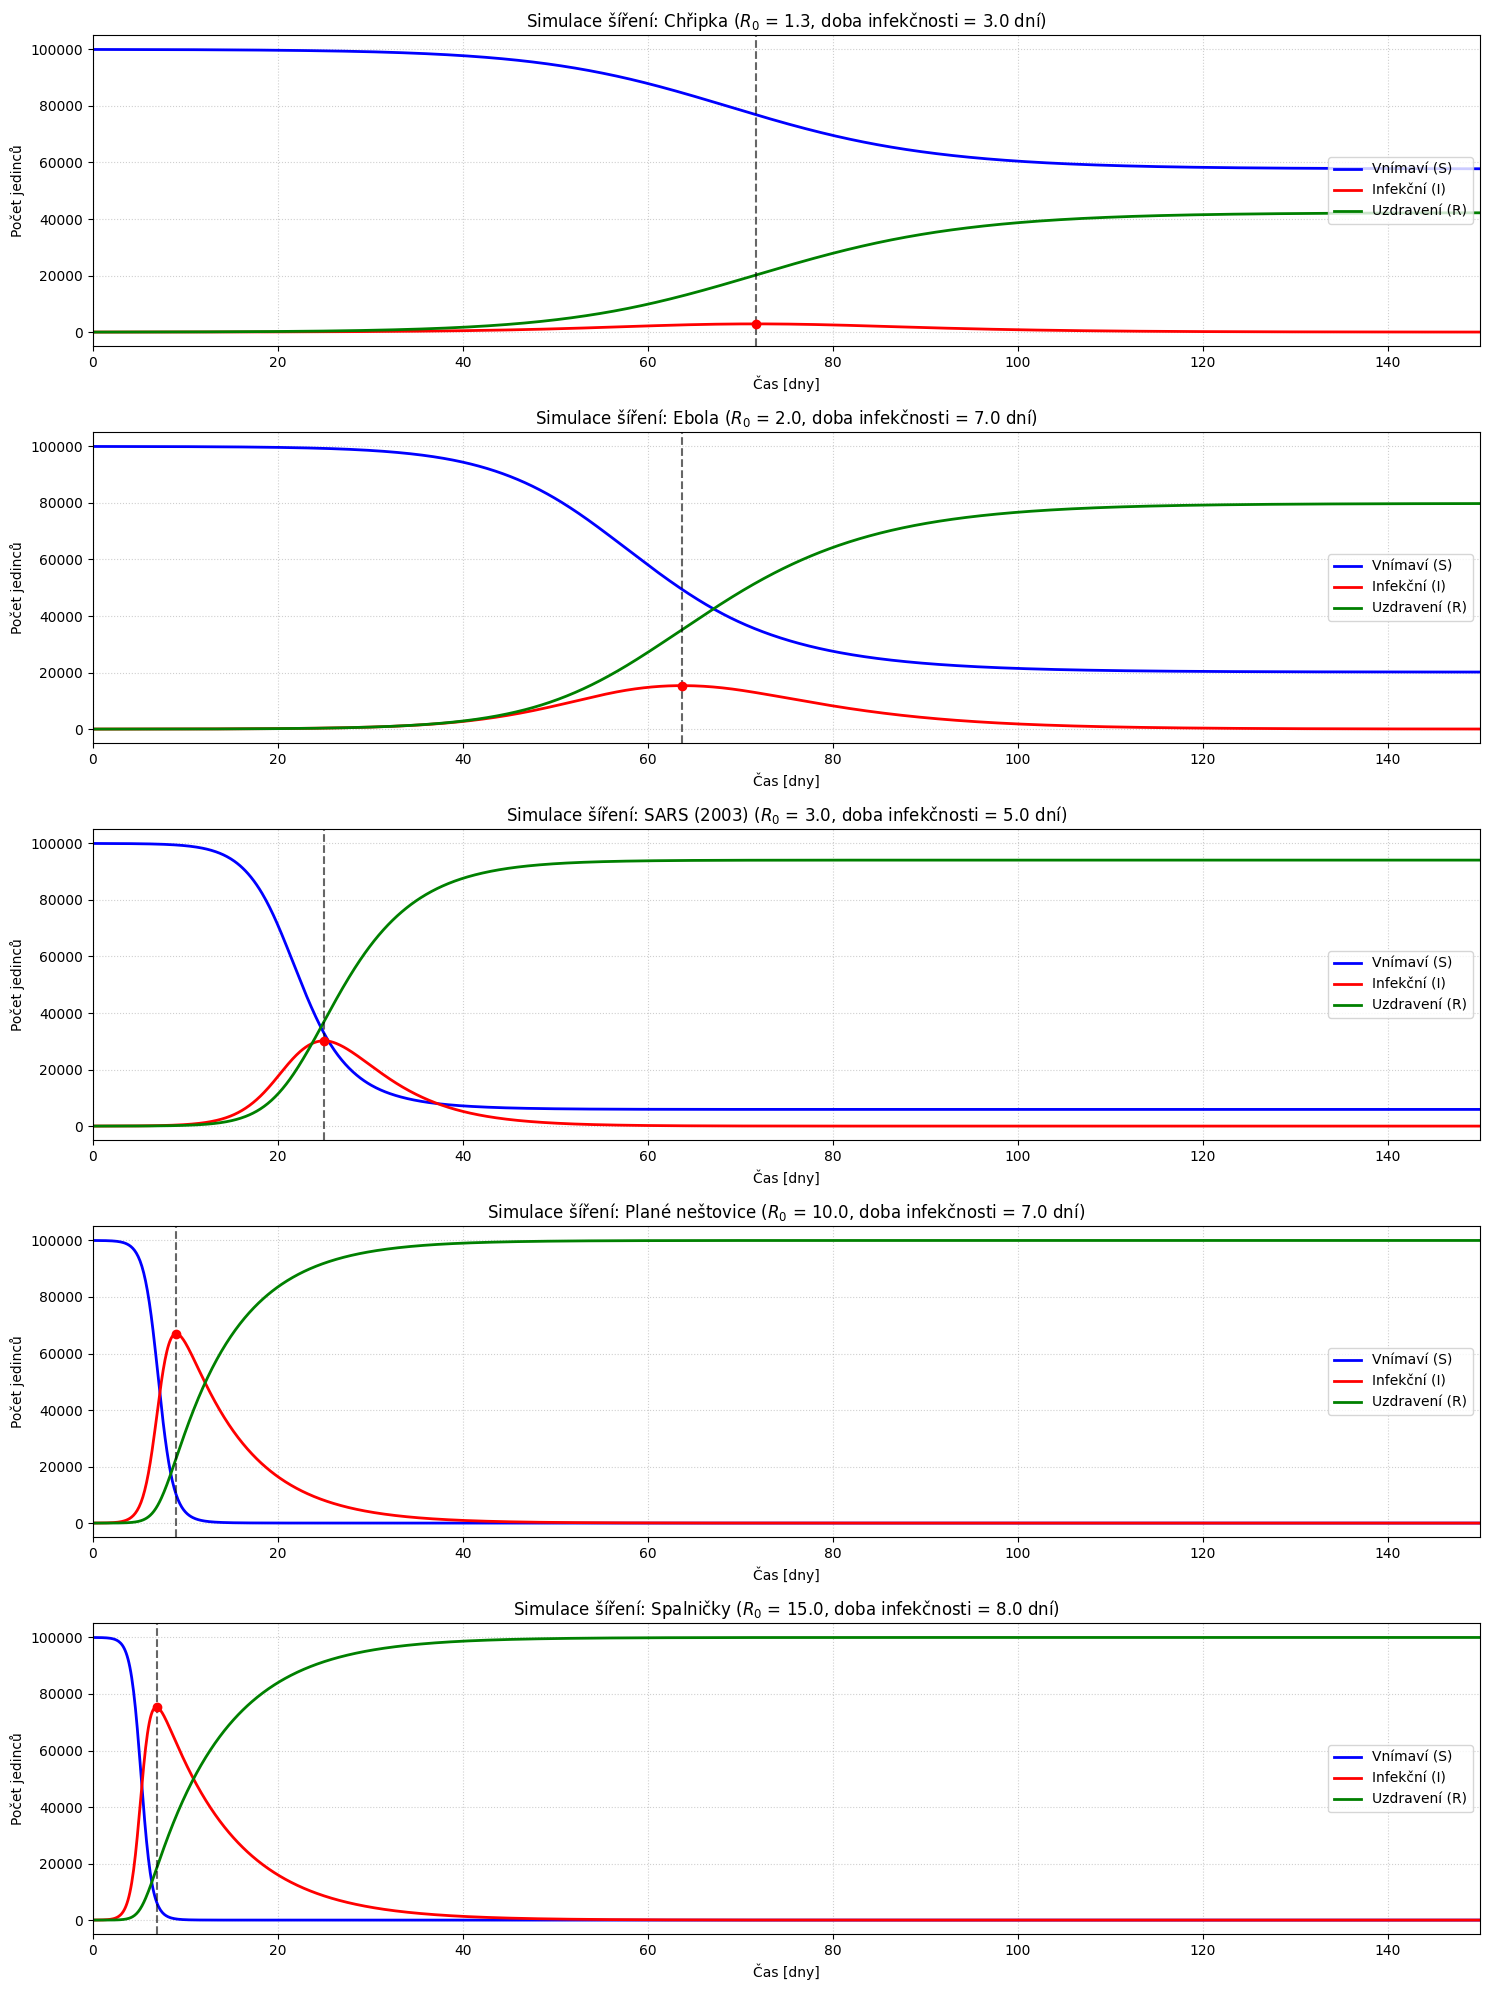

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def sir_model(t, y, N, beta, gamma):
    S, I, R = y
    dsdt = - (beta * S * I) / N
    didt = (beta * S * I) / N - gamma * I
    drdt = gamma * I
    return [dsdt, didt, drdt]

N = 100000      # Celková populace pro simulaci: 100 tisíc lidí)
I0 = 10            
R0_comp = 0         
S0 = N - I0 - R0_comp 
y0 = [S0, I0, R0_comp]

t_span = (0, 150)   # Časový horizont simulace (150 dní)
t_eval = np.linspace(t_span[0], t_span[1], 1500)

diseases = {
    'Chřipka': (1.3, 3.0),
    'Ebola': (2.0, 7.0),
    'SARS (2003)': (3.0, 5.0),
    'Plané neštovice': (10.0, 7.0),
    'Spalničky': (15.0, 8.0)
}

plt.figure(figsize=(15, 20))

results = {}

print("--- PŘESNÉ VÝSLEDKY SIMULACÍ ---")

for idx, (name, (R0_val, duration)) in enumerate(diseases.items(), 1):
    gamma = 1.0 / duration
    beta = R0_val * gamma
    
    sol = solve_ivp(sir_model, t_span, y0, args=(N, beta, gamma), t_eval=t_eval)
    results[name] = sol
    
    i_vse = sol.y[1]
    peak_idx = np.argmax(i_vse)
    peak_time = sol.t[peak_idx]
    peak_infected = i_vse[peak_idx]
    
    # Výpočet konce epidemie (kdy počet aktivně nakažených I klesne pod 1 jedince)
    end_indices = np.where((sol.t > peak_time) & (i_vse < 1.0))[0]
    if len(end_indices) > 0:
        duration_total = sol.t[end_indices[0]]
    else:
        duration_total = t_span[1]
        
    final_susceptible = sol.y[0][-1]
    final_onemocnelo = N - final_susceptible

    print(f"\n{name.upper()}:")
    print(f"  1. Vrchol epidemie nastane: {peak_time:.1f}. den (aktivně nakažených: {int(peak_infected)} lidí)")
    if duration_total < t_span[1]:
        print(f"  2. Epidemie potrvá: {duration_total:.1f} dní (než počet aktivních případů klesne pod 1)")
    else:
        print(f"  2. Epidemie potrvá: Více než {t_span[1]} dní (přetrvává i na konci simulace)")
    print(f"  3. Celkem onemocní: {int(final_onemocnelo)} lidí | Nákaze unikne: {int(final_susceptible)} lidí")
    
    plt.subplot(5, 1, idx)
    plt.plot(sol.t, sol.y[0], label='Vnímaví (S)', color='blue', lw=2)
    plt.plot(sol.t, sol.y[1], label='Infekční (I)', color='red', lw=2)
    plt.plot(sol.t, sol.y[2], label='Uzdravení (R)', color='green', lw=2)
    
    plt.axvline(x=peak_time, color='black', linestyle='--', alpha=0.6)
    plt.plot(peak_time, peak_infected, 'ro', markersize=6)
    
    plt.title(f'Simulace šíření: {name} ($R_0$ = {R0_val}, doba infekčnosti = {duration} dní)')
    plt.xlabel('Čas [dny]')
    plt.ylabel('Počet jedinců')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='right')
    plt.xlim(t_span)

plt.tight_layout()
plt.show()

---
## 3. Vyhodnocení simulace a odpovědi na otázky
(Nad grafy se nachází print příkazy, které jsem využil k získání dat během výpočtů. Čísla se mohou lehce lišit.)
Na základě získaných grafických průběhů ze simulace můžeme analyzovat chování jednotlivých chorob v čase:

#### 1. Chřipka ($R_0 = 1.3$)
* **Kdy dojde k vrcholu epidemie?** Vrchol nastává až přibližně **72. den** (71.7), kdy je v jeden okamžik nakaženo maximálně **2 903 jedinců**.
* **Jak dlouho epidemie potrvá?** Aktivní šíření trvá po celou dobu simulace. (182.7 dní, tudíž déle než simulovaných 150 dní)
* **Kolik jedinců nakonec onemocní a kolik ne?** **60 479 jedinců nákaze unikne** a zbytek populace, tedy **39 520 jedinců, během epidemie onemocní**.

#### 2. Ebola ($R_0 = 2.0$)
* **Kdy dojde k vrcholu epidemie?** K vrcholu epidemie dochází přibližně v **64. den**. (63.7), kdy je v jeden okamžik nakaženo maximálně **15 380 jedinců**.
* **Jak dlouho epidemie potrvá?** Aktivní šíření trvá po celou dobu simulace. (188.8 dní, tudíž déle než simulovaných 150 dní)
* **Kolik jedinců nakonec onemocní a kolik ne?** **21 463 jedinců nákaze unikne** a zbytek populace, tedy **78 536 jedinců, během epidemie onemocní**.

#### 3. SARS ($R_0 = 3.0$)
* **Kdy dojde k vrcholu epidemie?** Vyšší reprodukční číslo způsobuje strmější nárůst. Vrchol přichází poměrmente rychle, kolem **25. dne (30 178 jedinců)**.
* **Jak dlouho epidemie potrvá?** Epidemie má poměrně rychlý průběh a prakticky úplně vymizí kolem **93. dne**.
* **Kolik jedinců nakonec onemocní a kolik ne?** Pouhých **5 897 jedinců nákaze unikne** a zbytek populace, tedy **94 102 jedinců, během epidemie onemocní**.

#### 4. Plané neštovice ($R_0 = 10.0$)
* **Kdy dojde k vrcholu epidemie?** Extrémně nakažlivá choroba s rychlým nástupem. Explozivní nárůst kulminuje už **9. den 66 999 jedinců**.
* **Jak dlouho epidemie potrvá?** Má krátké trvání díky rychlému vyčerpání vnímavých jedinců. Epidemie zcela odezní do **89. dne** (88.1).
* **Kolik jedinců nakonec onemocní a kolik ne?** Pouhý **4 jedinci nákaze uniknou** a zbytek populace, tedy **99 995 jedinců, během epidemie onemocní**.

#### 5. Spalničky ($R_0 = 15.0$)
* **Kdy dojde k vrcholu epidemie?** Vrchol epidemie nastává bleskově již kolem **7. dne** (6.9) s maximálním počtem **nakažených jedinců 75 320**.
* **Jak dlouho epidemie potrvá?** Celá epidemie potrvá **98 dní** (97.5).
* **Kolik jedinců nakonec onemocní a kolik ne?** **Nákaze nikdo neuteče.**

### Obecný závěr SIR modelování
Z porovnání jednoznačně vyplývá, že **reprodukční číslo $R_0$ zásadním způsobem určuje rychlost a intenzitu epidemie**. Čím vyšší je hodnota $R_0$, tím dříve nastává vrchol epidemie, tím je tento vrchol vyšší (kritický nápor na populaci/zdravotnictví v jeden okamžik) a tím menší procento populace má šanci vlně epidemie uniknout bez nákazy. Zároveň však velmi agresivní epidemie s vysokým $R_0$ trvají kratší dobu, protože bleskově vyčerpají rezervoár vnímavých hostitelů (tzv. dosažení kolektivní imunity vyčerpáním vnímavých).

---
---
# Úloha 3: Vytvoření vlastního modelu (Mřížkový celulární automat)
---
## 1. Úvod modelu
Pro vlastní model jsem zvolil **mřížkový model typu celulární automat**, konkrétně slavnou **Conwayovu Hru života (Game of Life)**. Tento model simuluje dynamiku populace na diskrétní dvourozměrné mřížce, kde každá buňka může být ve dvou stavech: **živá** (1) nebo **mrtvá** (0).

Chování systému v čase není řízeno diferenciálními rovnicemi, ale sadou lokálních deterministických pravidel, která se synchronně aplikují na celou mřížku v každém časovém kroku (generaci). Stav každé buňky v příští generaci závisí výhradně na počtu živých sousedů v jejím bezprostředním okolí (tzv. Mooreovo okolí obsahující 8 sousedních buněk).

### Pravidla modelu:
1. **Smrt podvýživou:** Živá buňka s méně než 2 živými sousedy v příští generaci zemře.
2. **Život v rovnováze:** Živá buňka s 2 nebo 3 živými sousedy přežívá do další generace.
3. **Smrt přelidněním:** Živá buňka s více než 3 živými sousedy zemře.
4. **Reprodukce:** Mrtvá buňka s právě 3 živými sousedy ožije.

V modelu implementujeme periodické (toroidální) okrajové podmínky, což znamená, že horní okraj mřížky navazuje na spodní a levý na pravý. Tím eliminujeme zkreslení na okrajích a simulujeme nekonečný prostor. Sledujeme vývoj náhodné počáteční populace a analyzujeme, jak se mění hustota osídlení v čase.

---

## 2. Implementace v Pythonu

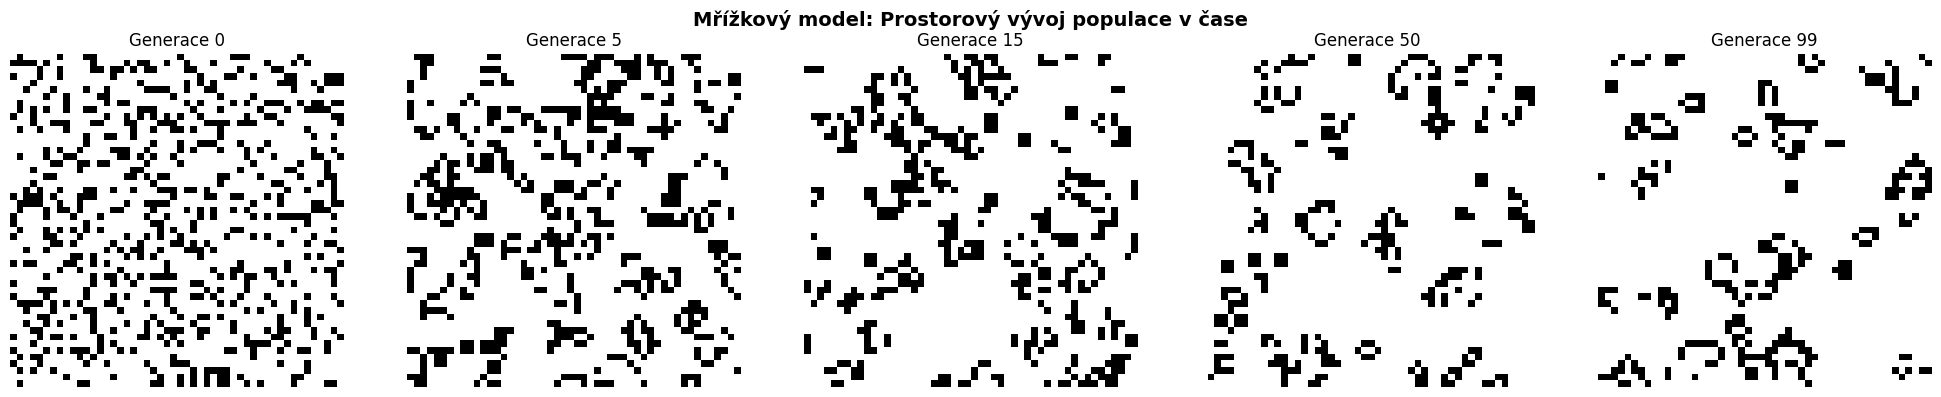

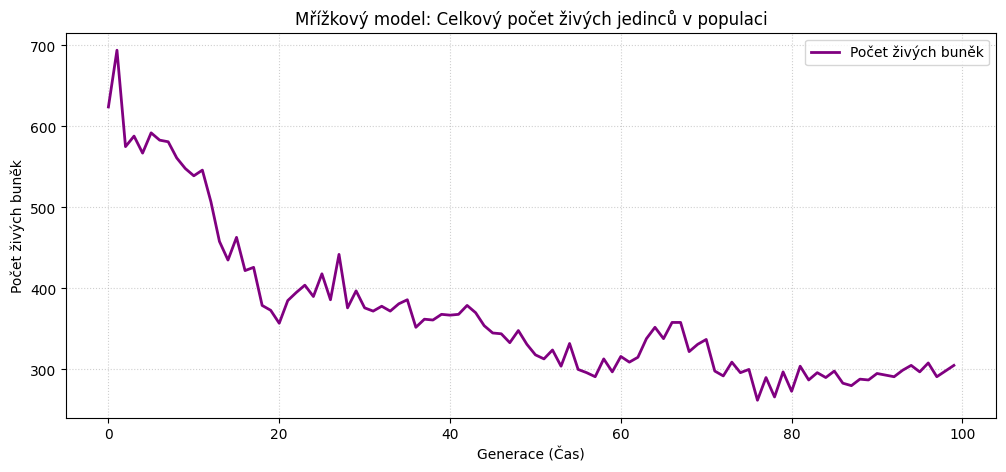

--- PŘESNÉ VÝSLEDKY MŘÍŽKOVÉHO MODELU ---
Počáteční počet živých buněk (Generace 0): 624 (z celkových 2500)
Počet živých buněk po 5 generacích: 592
Počet živých buněk po 50 generacích: 318
Konečný počet živých buněk (Generace 99): 305


In [34]:
import numpy as np
import matplotlib.pyplot as plt

N_grid = 50          # Velikost mřížky (50x50 buněk)
generations = 100    # Počet časových kroků (generací)
p_alive = 0.25       # Počáteční hustota osídlení (25 % buněk bude živých)

np.random.seed(42)   # Fixace seedu pro reprodukovatelnost výsledků
grid = np.random.choice([0, 1], size=(N_grid, N_grid), p=[1 - p_alive, p_alive])

history_alive = []
history_grid_steps = {}  # Uložíme si vybrané kroky pro zobrazení vývoje

def update_grid(current_grid):
    new_grid = current_grid.copy()
    rows, cols = current_grid.shape
    
    for r in range(rows):
        for c in range(cols):
            total_neighbors = int(
                current_grid[(r-1)%rows, (c-1)%cols] + current_grid[(r-1)%rows, c] + current_grid[(r-1)%rows, (c+1)%cols] +
                current_grid[r, (c-1)%cols]                                       + current_grid[r, (c+1)%cols] +
                current_grid[(r+1)%rows, (c-1)%cols] + current_grid[(r+1)%rows, c] + current_grid[(r+1)%rows, (c+1)%cols]
            )
            
            # Aplikace Conwayových pravidel
            if current_grid[r, c] == 1:
                if total_neighbors < 2 or total_neighbors > 3:
                    new_grid[r, c] = 0  # Smrt podvýživou nebo přelidněním
            else:
                if total_neighbors == 3:
                    new_grid[r, c] = 1  # Reprodukce (oživení)
                    
    return new_grid

current_state = grid.copy()
for step in range(generations):
    num_alive = np.sum(current_state)
    history_alive.append(num_alive)
    
    if step in [0, 5, 15, 50, 99]:
        history_grid_steps[step] = current_state.copy()
        
    current_state = update_grid(current_state)

# --- VYKRESLENÍ VÝSLEDKŮ 1: VÝVOJ MŘÍŽKY V ČASE ---
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
steps_to_show = [0, 5, 15, 50, 99]

for idx, step in enumerate(steps_to_show):
    axs[idx].imshow(history_grid_steps[step], cmap='binary', interpolation='nearest')
    axs[idx].set_title(f'Generace {step}')
    axs[idx].axis('off')

plt.suptitle('Mřížkový model: Prostorový vývoj populace v čase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(range(generations), history_alive, color='purple', lw=2, label='Počet živých buněk')
plt.title('Mřížkový model: Celkový počet živých jedinců v populaci')
plt.xlabel('Generace (Čas)')
plt.ylabel('Počet živých buněk')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# --- VÝPIS STATISTIKY ---
print("--- PŘESNÉ VÝSLEDKY MŘÍŽKOVÉHO MODELU ---")
print(f"Počáteční počet živých buněk (Generace 0): {history_alive[0]} (z celkových {N_grid*N_grid})")
print(f"Počet živých buněk po 5 generacích: {history_alive[5]}")
print(f"Počet živých buněk po 50 generacích: {history_alive[50]}")
print(f"Konečný počet živých buněk (Generace 99): {history_alive[-1]}")